#  SHAP for Linear Models 1

In [2]:
import pandas as pd

# set the fule URl and filename
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv'
filename = 'wine.csv'

# Check if the file is in the current directory
try:
    wine = pd.read_csv(filename)
except FileNotFoundError:
    print(f'Downloading {filename}from {url} ...')
    wine = pd.read_csv(url, sep=";")
    wine.to_csv(filename, index=False)
    print('Download complete!')
        

In [3]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Feature Analysis

In [5]:
from tabulate import tabulate
summary = wine.describe().transpose().round(2)
summary = summary.drop("count", axis=1)

# create a markdown table
markdown_table = tabulate(
    summary, headers='keys', tablefmt='pipe'
)
print(markdown_table)

|                      |   mean |   std |   min |    25% |    50% |    75% |    max |
|:---------------------|-------:|------:|------:|-------:|-------:|-------:|-------:|
| fixed acidity        |   6.85 |  0.84 |  3.8  |   6.3  |   6.8  |   7.3  |  14.2  |
| volatile acidity     |   0.28 |  0.1  |  0.08 |   0.21 |   0.26 |   0.32 |   1.1  |
| citric acid          |   0.33 |  0.12 |  0    |   0.27 |   0.32 |   0.39 |   1.66 |
| residual sugar       |   6.39 |  5.07 |  0.6  |   1.7  |   5.2  |   9.9  |  65.8  |
| chlorides            |   0.05 |  0.02 |  0.01 |   0.04 |   0.04 |   0.05 |   0.35 |
| free sulfur dioxide  |  35.31 | 17.01 |  2    |  23    |  34    |  46    | 289    |
| total sulfur dioxide | 138.36 | 42.5  |  9    | 108    | 134    | 167    | 440    |
| density              |   0.99 |  0    |  0.99 |   0.99 |   0.99 |   1    |   1.04 |
| pH                   |   3.19 |  0.15 |  2.72 |   3.09 |   3.18 |   3.28 |   3.82 |
| sulphates            |   0.49 |  0.11 |  0.22 |   0.

## Fitting a Linear Regression Model

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
y = wine['quality']
X = wine.drop('quality', axis=1)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Evaluate Model

In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print(f"MAE: {mae:.3f}")
print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")

MAE: 0.587
MSE: 0.571
RMSE: 0.756


### Interpreting the Coefficients

In [15]:
coefs = pd.DataFrame({
    'feature': X.columns.values,
    'coefficient': np.round(model.coef_, 3)
}) 
print(coefs.to_markdown(index=False))

| feature              |   coefficient |
|:---------------------|--------------:|
| fixed acidity        |         0.06  |
| volatile acidity     |        -1.928 |
| citric acid          |         0.034 |
| residual sugar       |         0.075 |
| chlorides            |         0.268 |
| free sulfur dioxide  |         0.004 |
| total sulfur dioxide |        -0.001 |
| density              |      -129.947 |
| pH                   |         0.597 |
| sulphates            |         0.539 |
| alcohol              |         0.217 |


## SHAP Values

In [17]:
import shap
explainer = shap.LinearExplainer(model, X_train)

In [18]:
shap_values = explainer(X_test)

In [19]:
# print(shap_values)

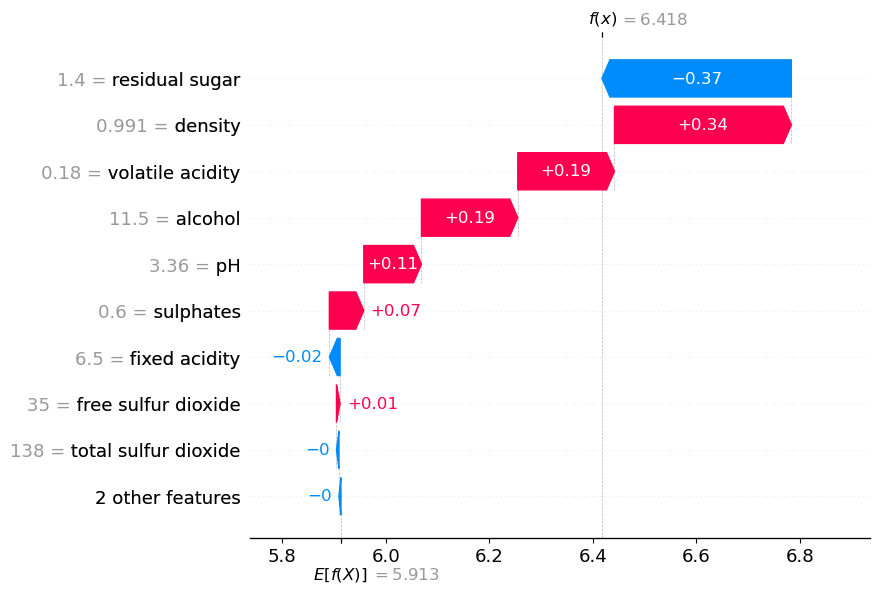

In [20]:
shap.plots.waterfall(shap_values[0])

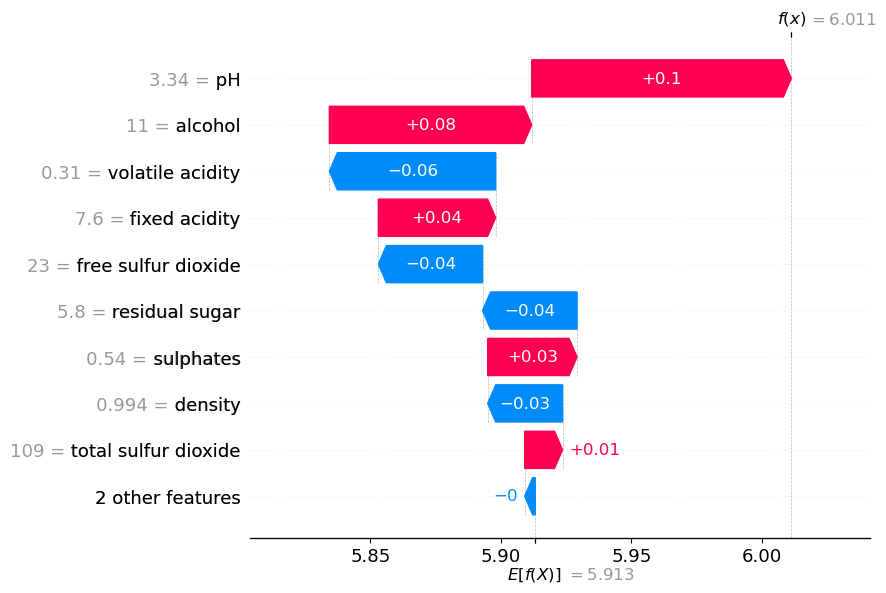

In [21]:
shap.plots.waterfall(shap_values[1])

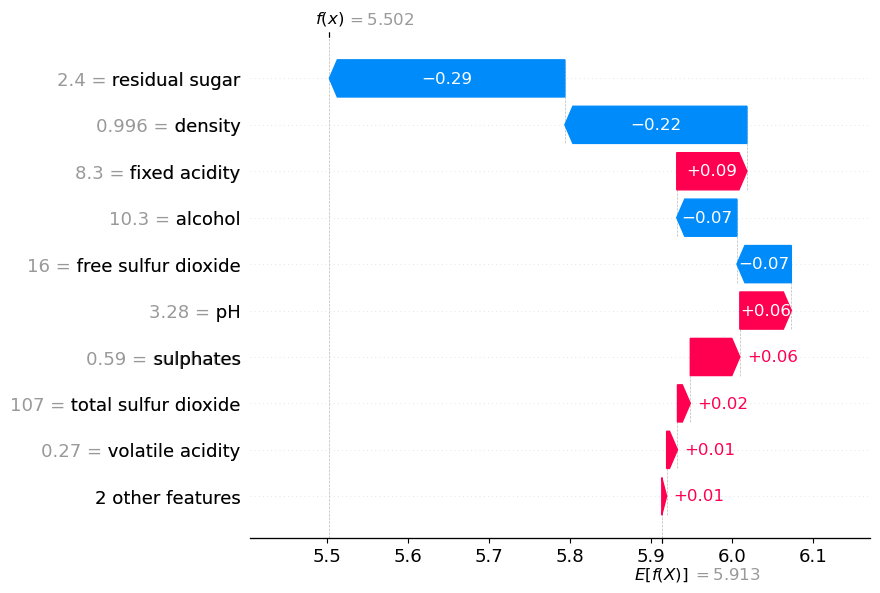

In [22]:
shap.plots.waterfall(shap_values[2])

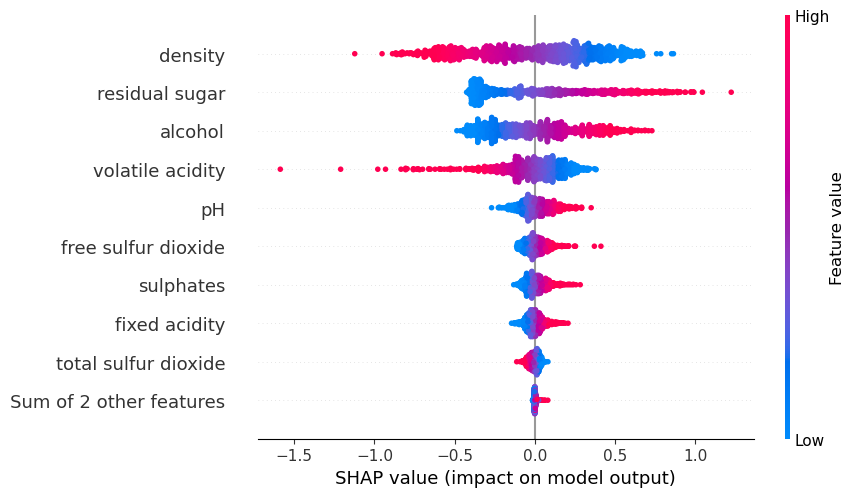

In [23]:
shap.plots.beeswarm(shap_values)

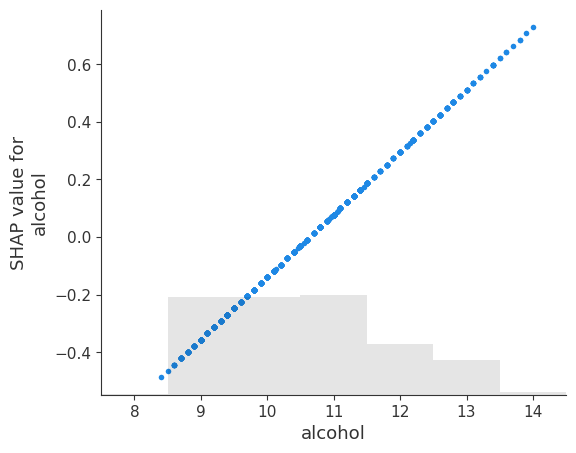

In [24]:
shap.plots.scatter(shap_values[:, 'alcohol'])

In [25]:
feature = 'alcohol'
ind = X_test.columns.get_loc(feature)
coefs.coefficient[ind]

0.217

In [26]:
shap_values

.values =
array([[-2.07061950e-02,  1.86886330e-01, -2.75327692e-05, ...,
         1.11408850e-01,  6.65600577e-02,  1.86043706e-01],
       [ 4.49330398e-02, -6.37090583e-02, -2.09249046e-03, ...,
         9.94743186e-02,  3.42493501e-02,  7.75423224e-02],
       [ 8.67034619e-02,  1.33972150e-02,  2.03742492e-03, ...,
         6.36707246e-02,  6.11749397e-02, -7.43596151e-02],
       ...,
       [ 5.68674461e-02, -5.87935334e-03, -3.71692384e-04, ...,
        -1.96919767e-03, -4.65274189e-02, -7.43596151e-02],
       [-7.44110234e-02,  1.77248046e-01,  5.47902107e-03, ...,
         2.24786898e-01, -1.42167113e-02, -7.43596151e-02],
       [ 9.26706651e-02,  1.48333193e-01,  1.69326530e-03, ...,
         9.94743186e-02,  1.85032652e-01, -3.78163490e-01]])

.base_values =
array([5.91320493, 5.91320493, 5.91320493, 5.91320493, 5.91320493,
       5.91320493, 5.91320493, 5.91320493, 5.91320493, 5.91320493,
       5.91320493, 5.91320493, 5.91320493, 5.91320493, 5.91320493,
       5.9132049

In [27]:
bob = pd.DataFrame(shap_values.values, columns=X.columns)

In [28]:
bob

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,-0.020706,0.186886,-0.000028,-0.365900,-0.003830,0.006929,-0.004684,0.341671,0.111409,0.066560,0.186044
1,0.044933,-0.063709,-0.002092,-0.036227,-0.001955,-0.039914,0.014503,-0.028679,0.099474,0.034249,0.077542
2,0.086703,0.013397,0.002037,-0.290974,0.003937,-0.067238,0.015827,-0.224900,0.063671,0.061175,-0.074360
3,0.003163,-0.025156,-0.003469,0.173565,0.003402,0.088903,-0.055631,-0.380837,-0.001969,-0.019602,-0.399864
4,-0.038608,0.148333,-0.000716,-0.395870,-0.003295,-0.043817,0.038323,0.444329,0.039802,0.023479,0.142643
...,...,...,...,...,...,...,...,...,...,...,...
975,0.128474,0.013397,0.000661,-0.103660,-0.004098,-0.024299,0.023766,0.073979,-0.079544,-0.041142,0.142643
976,0.062835,-0.025156,0.002037,0.031207,-0.001955,-0.106274,0.009210,-0.003989,-0.031806,-0.030372,0.012441
977,0.056867,-0.005879,-0.000372,0.203536,-0.001955,0.003025,0.010533,-0.185916,-0.001969,-0.046527,-0.074360
978,-0.074411,0.177248,0.005479,-0.388377,-0.003562,-0.020396,0.009210,0.255906,0.224787,-0.014217,-0.074360


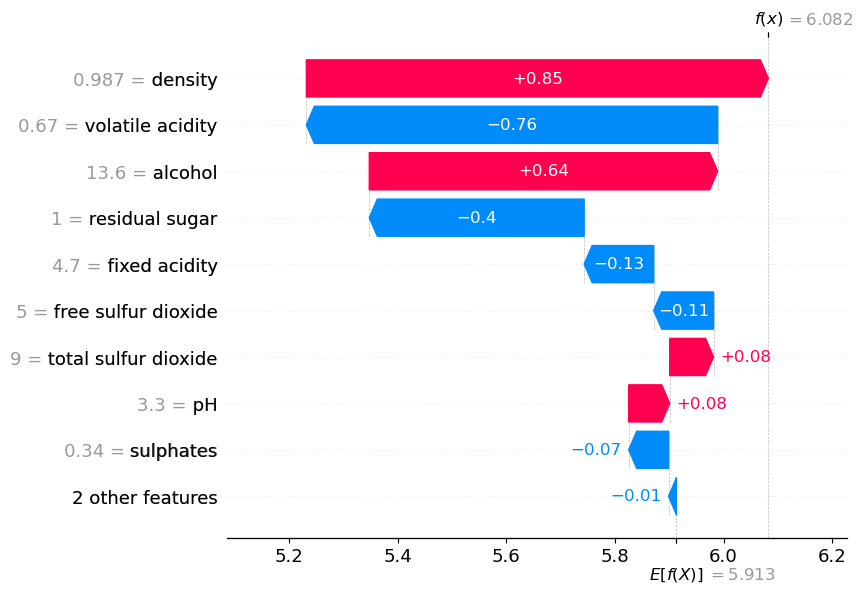

In [29]:
shap.plots.waterfall(shap_values[10])